In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [46]:
df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [47]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [48]:
df = df[['title',
         'type',
         'director',
         'cast',
         'country',
         'date_added',
         'release_year',
         'rating',
         'duration',
         'listed_in',
         'description']]

df.head()

,title,type,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,Dick Johnson Is Dead,Movie,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,Blood & Water,TV Show,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,Ganglands,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,Jailbirds New Orleans,TV Show,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,Kota Factory,TV Show,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [49]:
df.fillna('', inplace=True)

In [50]:
df['combined_features'] = (
    df['listed_in'] + ' ' +
    df['director'] + ' ' +
    df['cast'] + ' ' +
    df['description']
)

In [51]:
tfidf = TfidfVectorizer(stop_words='english')

feature_matrix = tfidf.fit_transform(df['combined_features'])

In [52]:
cosine_sim = cosine_similarity(feature_matrix)

In [53]:
def recommend_movie(title):

    title = title.lower()

    movie_titles = df['title'].str.lower()

    if title not in movie_titles.values:
        return "Movie not found!"

    idx = movie_titles[movie_titles == title].index[0]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:11]

    recommendations = []

    for movie in similarity_scores:
        recommendations.append(df.iloc[movie[0]]['title'])

    return recommendations

In [54]:
recommend_movie("Stranger Things")

['Beyond Stranger Things',
 'Prank Encounters',
 'The Umbrella Academy',
 'Anjaan: Special Crimes Unit',
 'Eli',
 'Safe Haven',
 'Homefront',
 'Kiss Me First',
 'Good Witch',
 'Equilibrium']

In [55]:
recommend_movie("The Irishman")

['The Irishman: In Conversation',
 'GoodFellas',
 'Raging Bull',
 "Who's That Knocking at My Door?",
 'Mean Streets',
 'Rolling Thunder Revue: A Bob Dylan Story by Martin Scorsese',
 'Sebastian Maniscalco: Why Would You Do That',
 'Gangs of New York',
 'The Departed',
 'Sebastian Maniscalco: Stay Hungry']

C:\Users\soura\AppData\Local\Temp\ipykernel_22568\4278893465.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


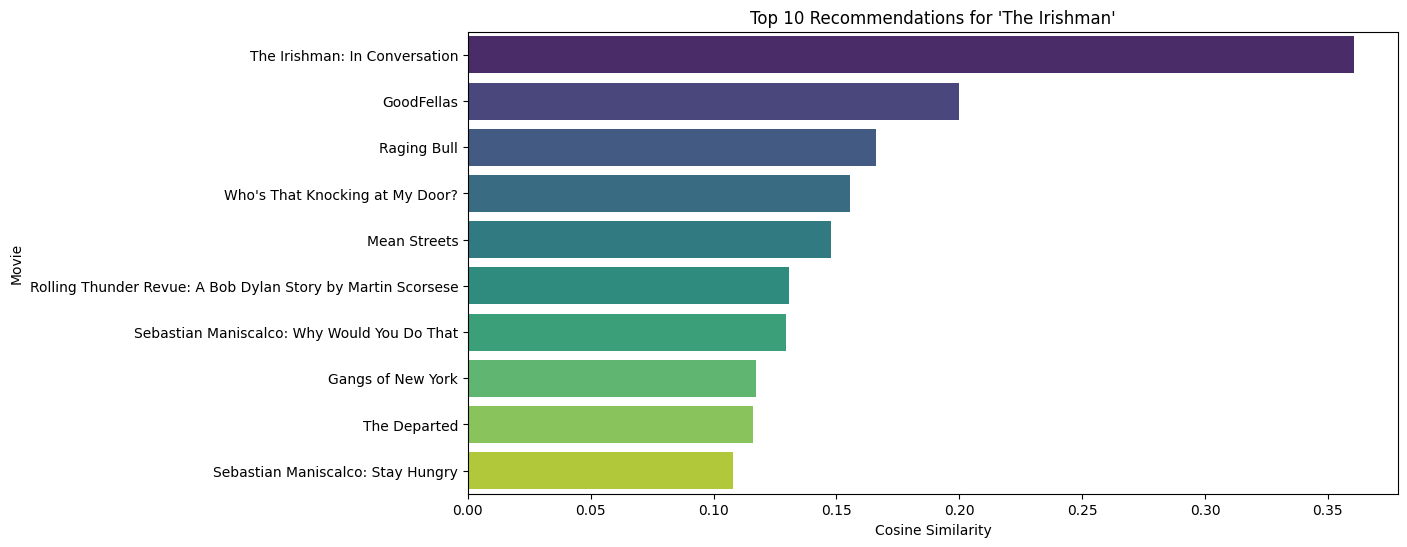

In [63]:
movie = "The Irishman"

idx = df[df['title'] == movie].index[0]

scores = list(enumerate(cosine_sim[idx]))

scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:11]

titles = [df.iloc[i[0]]['title'] for i in scores]
values = [i[1] for i in scores]

plt.figure(figsize=(12,6))

sns.barplot(
    x=values,
    y=titles,
    palette='viridis'
)

plt.title(f"Top 10 Recommendations for '{movie}'")

plt.xlabel("Cosine Similarity")

plt.ylabel("Movie")

plt.show()

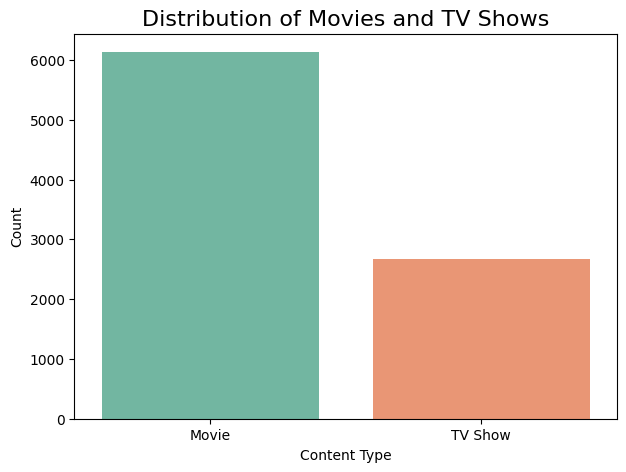

In [56]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)

plt.title("Distribution of Movies and TV Shows", fontsize=16)
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

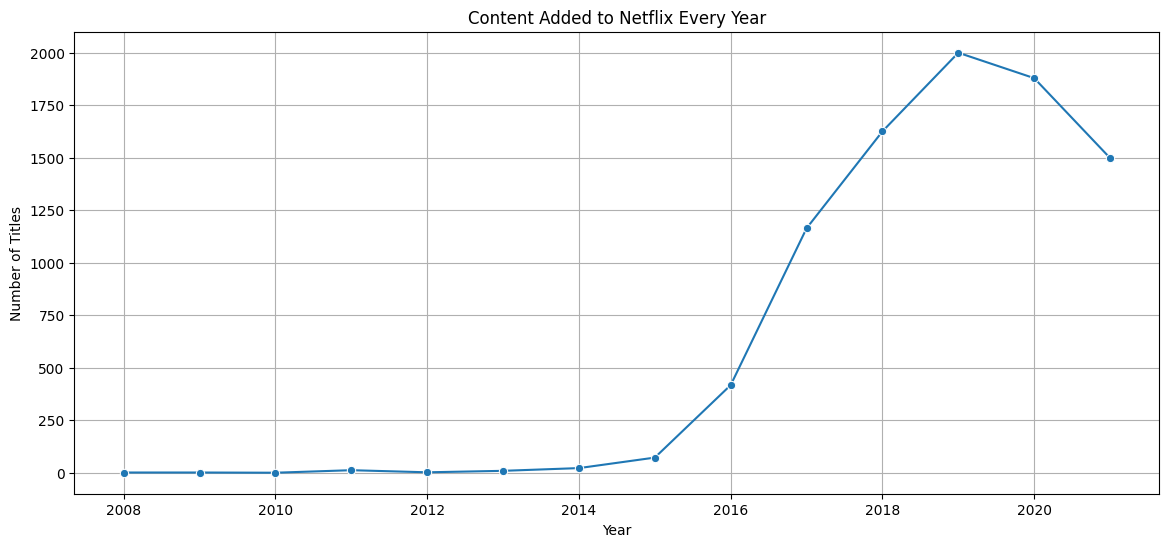

In [57]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

added = df['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(14,6))

sns.lineplot(
    x=added.index,
    y=added.values,
    marker='o'
)

plt.title("Content Added to Netflix Every Year")

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.grid(True)

plt.show()

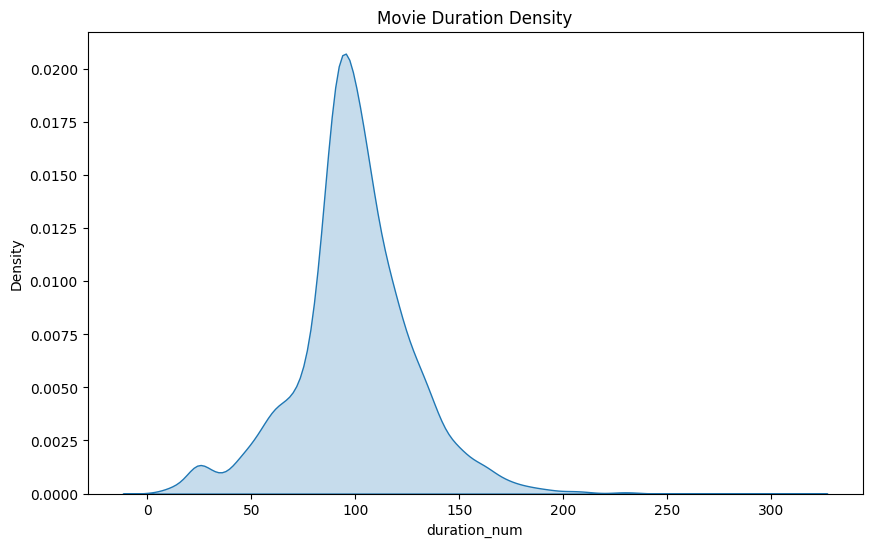

In [68]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    movies['duration_num'],
    fill=True
)

plt.title("Movie Duration Density")

plt.show()

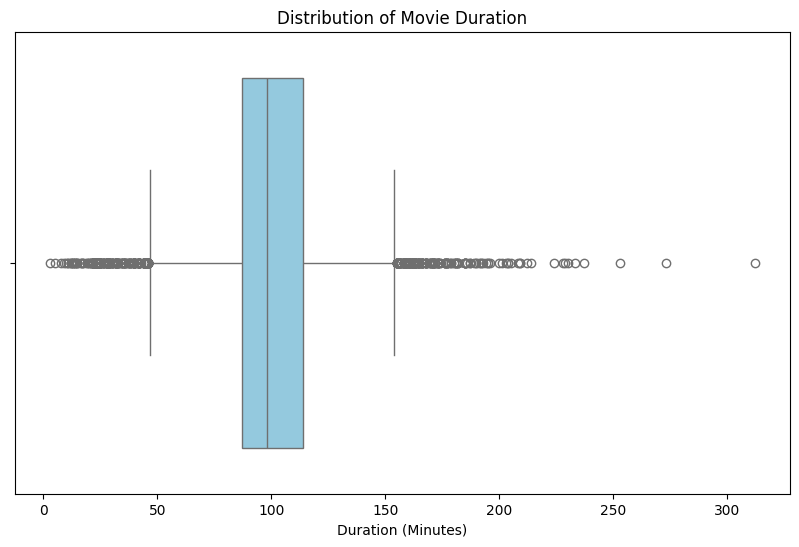

In [58]:
movies = df[df['type']=="Movie"].copy()

movies['duration_num'] = movies['duration'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,6))

sns.boxplot(
    x=movies['duration_num'],
    color='skyblue'
)

plt.title("Distribution of Movie Duration")

plt.xlabel("Duration (Minutes)")

plt.show()

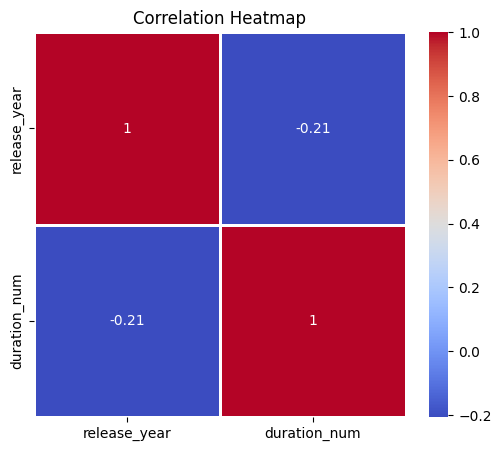

In [61]:
numeric = movies[['release_year','duration_num']]

plt.figure(figsize=(6,5))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title("Correlation Heatmap")

plt.show()

C:\Users\soura\AppData\Local\Temp\ipykernel_22568\1771224883.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


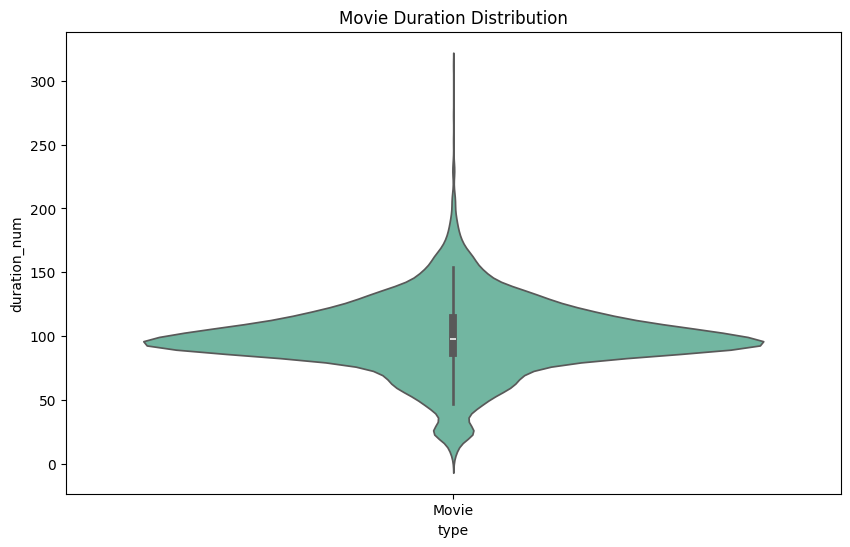

In [69]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=movies,
    x='type',
    y='duration_num',
    palette='Set2'
)

plt.title("Movie Duration Distribution")

plt.show()

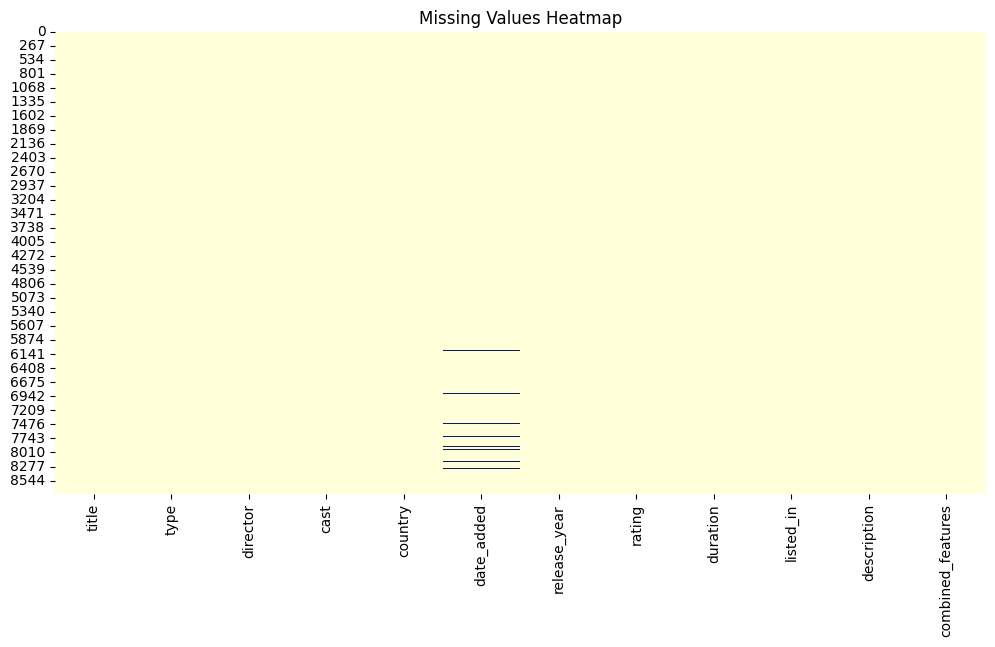

In [70]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='YlGnBu'
)

plt.title("Missing Values Heatmap")

plt.show()

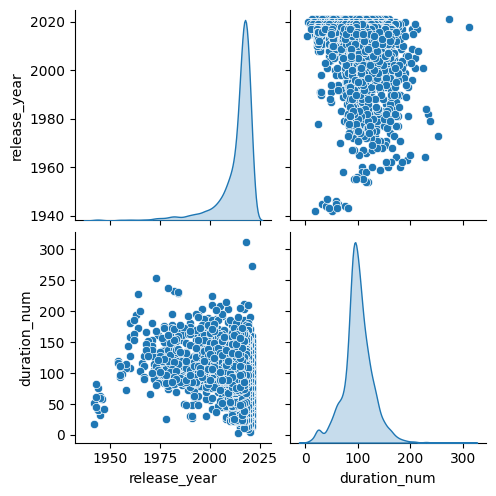

In [62]:
sns.pairplot(
    numeric,
    diag_kind='kde'
)

plt.show()

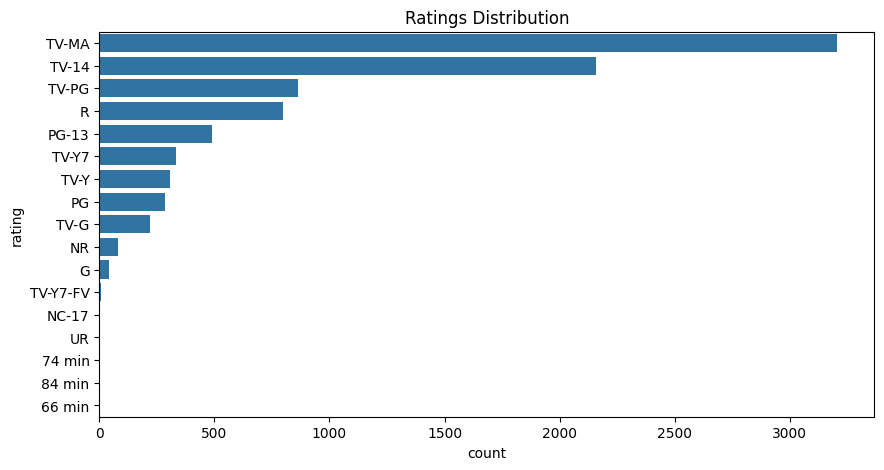

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=pd.read_csv("netflix_titles.csv"),
    y='rating',
    order=pd.read_csv("netflix_titles.csv")['rating'].value_counts().index
)

plt.title("Ratings Distribution")

plt.show()

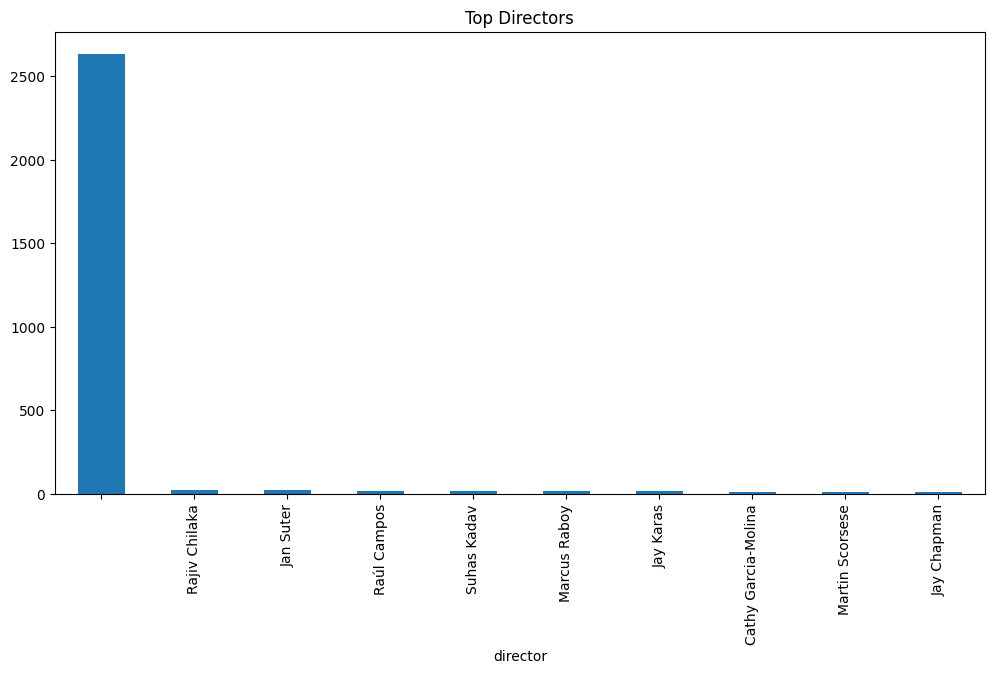

In [18]:
director = df['director'].str.split(', ').explode()

plt.figure(figsize=(12,6))

director.value_counts().head(10).plot(kind='bar')

plt.title("Top Directors")

plt.show()

In [19]:
movie = "The Irishman"

print("Recommendations for:", movie)

for i, rec in enumerate(recommend_movie(movie),1):
    print(i, rec)

Recommendations for: The Irishman
1 The Irishman: In Conversation
2 GoodFellas
3 Raging Bull
4 Who's That Knocking at My Door?
5 Mean Streets
6 Rolling Thunder Revue: A Bob Dylan Story by Martin Scorsese
7 Sebastian Maniscalco: Why Would You Do That
8 Gangs of New York
9 The Departed
10 Sebastian Maniscalco: Stay Hungry


In [43]:
movie = "Kota Factory"

print("Recommendations for:", movie)

for i, rec in enumerate(recommend_movie(movie),1):
    print(i, rec)

Recommendations for: Kota Factory
1 Yeh Meri Family
2 Girls Hostel
3 Chaman Bahaar
4 Betaal
5 The Creative Indians
6 Single Ladies Senior
7 Engineering Girls
8 Guru Aur Bhole
9 Glow Up
10 Dancing Angels


#  Conclusion

In this project, a Content-Based Movie Recommendation System was successfully developed using TF-IDF Vectorization and Cosine Similarity.

The recommendation engine analyzes movie descriptions, genres, directors, and cast members to identify similar content and suggest personalized recommendations.

This project demonstrates practical applications of:

- Machine Learning
- Natural Language Processing
- Feature Engineering
- Recommendation Systems
- Exploratory Data Analysis